In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Titanic-Dataset.csv')

In [35]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
print("First 5 rows of the DataFrame:")
print(df.head())

First 5 rows of the DataFrame:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            3734

In [4]:
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
print("Initial missing values:")
print(df.isnull().sum())

Initial missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
# Fill missing 'Age' values with the median
median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)
print(f"\nMissing 'Age' values filled with median: {median_age}")


Missing 'Age' values filled with median: 28.0


C:\Users\Administrator\AppData\Local\Temp\ipykernel_48964\3561584719.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_age, inplace=True)


In [7]:
# Fill missing 'Embarked' values with the mode
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(mode_embarked, inplace=True)
print(f"Missing 'Embarked' values filled with mode: {mode_embarked}")

Missing 'Embarked' values filled with mode: S


C:\Users\Administrator\AppData\Local\Temp\ipykernel_48964\2611426901.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(mode_embarked, inplace=True)


In [8]:
# Drop 'Cabin' column due to high number of missing values
df.drop('Cabin', axis=1, inplace=True)
print("\n'Cabin' column dropped.")


'Cabin' column dropped.


In [9]:
# Check for and remove duplicate rows
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - df.shape[0]
print(f"\nNumber of duplicate rows removed: {duplicates_removed}")


Number of duplicate rows removed: 0


In [10]:
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [11]:
print("\nDataFrame Info after cleaning:")
df.info()


DataFrame Info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [13]:
print("\nDescriptive statistics for 'Age':")
print(df['Age'].describe())



Descriptive statistics for 'Age':
count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64


In [14]:
print("\nDescriptive statistics for 'Fare':")
print(df['Fare'].describe())


Descriptive statistics for 'Fare':
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


In [15]:
print("\nValue counts for 'Pclass':")
print(df['Pclass'].value_counts())


Value counts for 'Pclass':
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [16]:
print("\nValue counts for 'Gender':")
print(df['Sex'].value_counts())


Value counts for 'Gender':
Sex
male      577
female    314
Name: count, dtype: int64


In [17]:
print("\nValue counts for 'Survived':")
print(df['Survived'].value_counts())


Value counts for 'Survived':
Survived
0    549
1    342
Name: count, dtype: int64


In [18]:
print("\nValue counts for 'Embarked':")
print(df['Embarked'].value_counts())


Value counts for 'Embarked':
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


In [32]:
print("\nSurvival rate by Gender:")
print(df.groupby('Sex')['Survived'].mean())


Survival rate by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [20]:
print("\nSurvival rate by Pclass:")
print(df.groupby('Pclass')['Survived'].mean())


Survival rate by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [21]:
print("\nSurvival rate by Embarked:")
print(df.groupby('Embarked')['Survived'].mean())


Survival rate by Embarked:
Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


In [22]:
print("\nAge distribution grouped by Survived status:")
print(df.groupby('Survived')['Age'].describe())


Age distribution grouped by Survived status:
          count       mean        std   min   25%   50%   75%   max
Survived                                                           
0         549.0  30.028233  12.499986  1.00  23.0  28.0  35.0  74.0
1         342.0  28.291433  13.764425  0.42  21.0  28.0  35.0  80.0


In [23]:
print("\nFare distribution grouped by Survived status:")
print(df.groupby('Survived')['Fare'].describe())


Fare distribution grouped by Survived status:
          count       mean        std  min      25%   50%   75%       max
Survived                                                                 
0         549.0  22.117887  31.388207  0.0   7.8542  10.5  26.0  263.0000
1         342.0  48.395408  66.596998  0.0  12.4750  26.0  57.0  512.3292


In [25]:
#Generate Visualizations

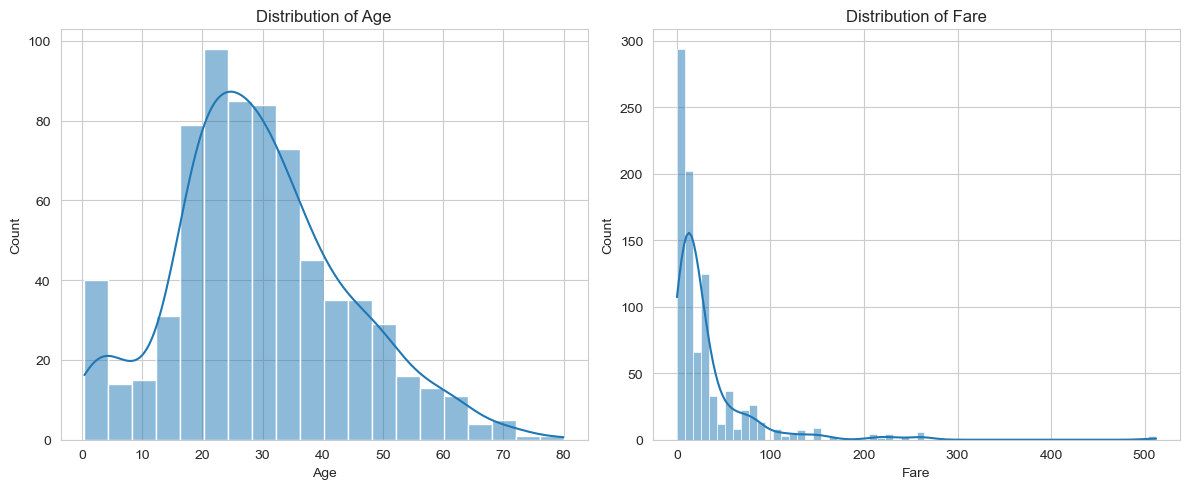

In [27]:
# Set style for plots
sns.set_style('whitegrid')

# 2. Histograms for numerical features
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(df['Fare'], kde=True)
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_48964\2465545138.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived', palette='viridis')


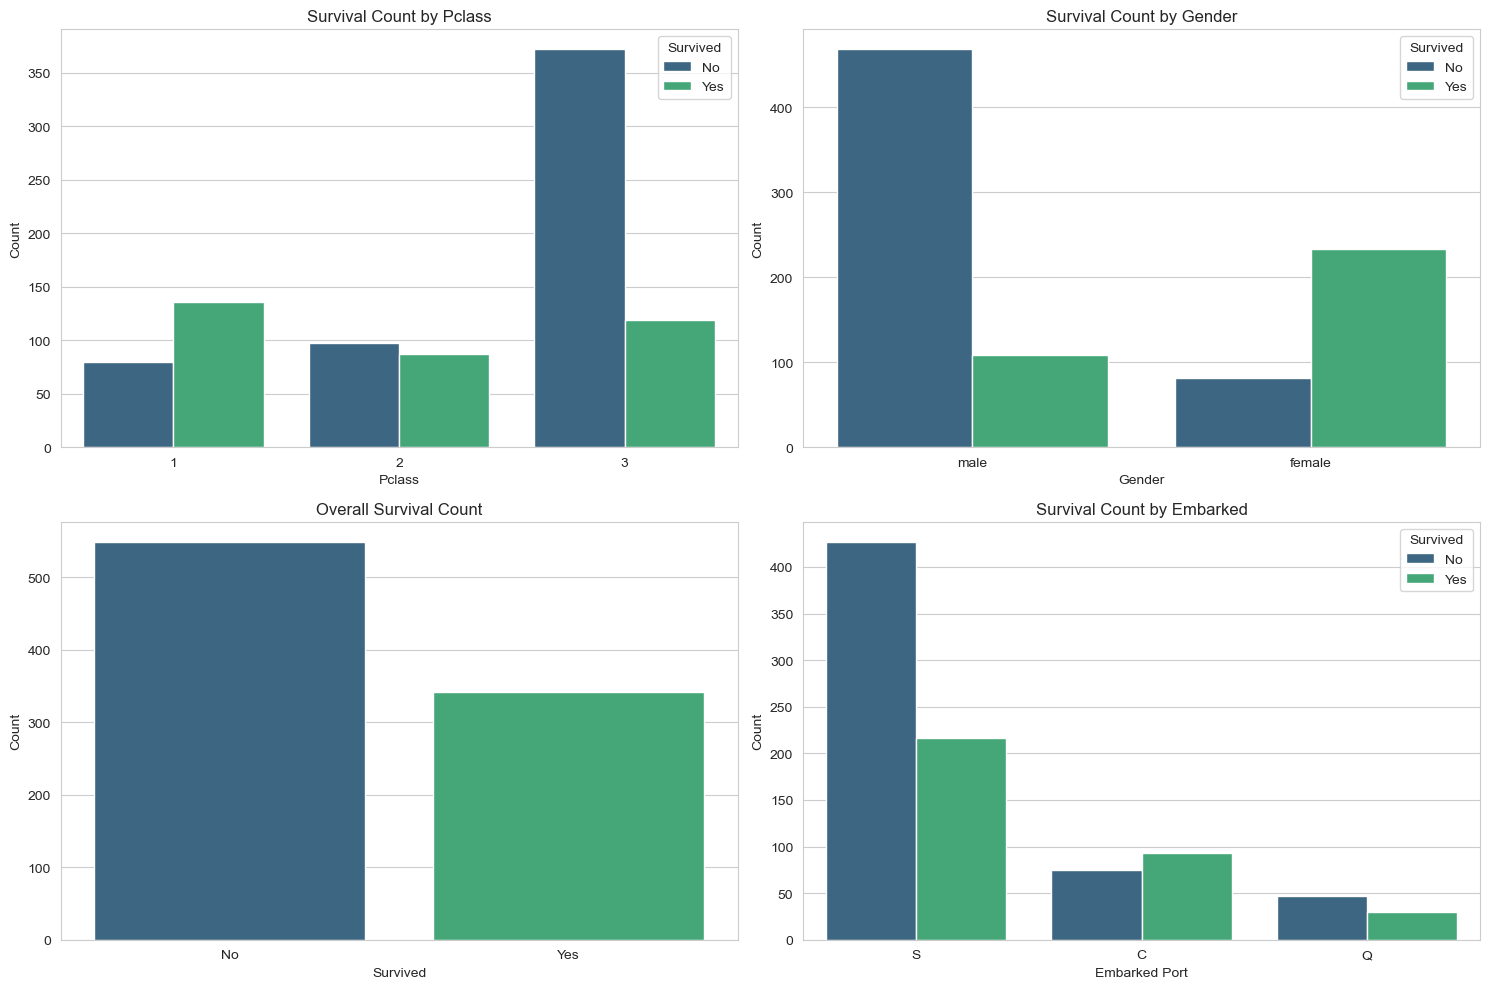

In [33]:
# 3. Count plots for categorical features
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Pclass', hue='Survived', palette='viridis')
plt.title('Survival Count by Pclass')
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])

plt.subplot(2, 2, 2)
sns.countplot(data=df, x='Sex', hue='Survived', palette='viridis')
plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])

plt.subplot(2, 2, 3)
sns.countplot(data=df, x='Survived', palette='viridis')
plt.title('Overall Survival Count')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])

plt.subplot(2, 2, 4)
sns.countplot(data=df, x='Embarked', hue='Survived', palette='viridis')
plt.title('Survival Count by Embarked')
plt.xlabel('Embarked Port')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_48964\3292661252.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Survived', y='Age', palette='viridis')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_48964\3292661252.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Survived', y='Fare', palette='viridis')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_48964\3292661252.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Age', palette='viridis')
C:\Users\Administrator\AppData

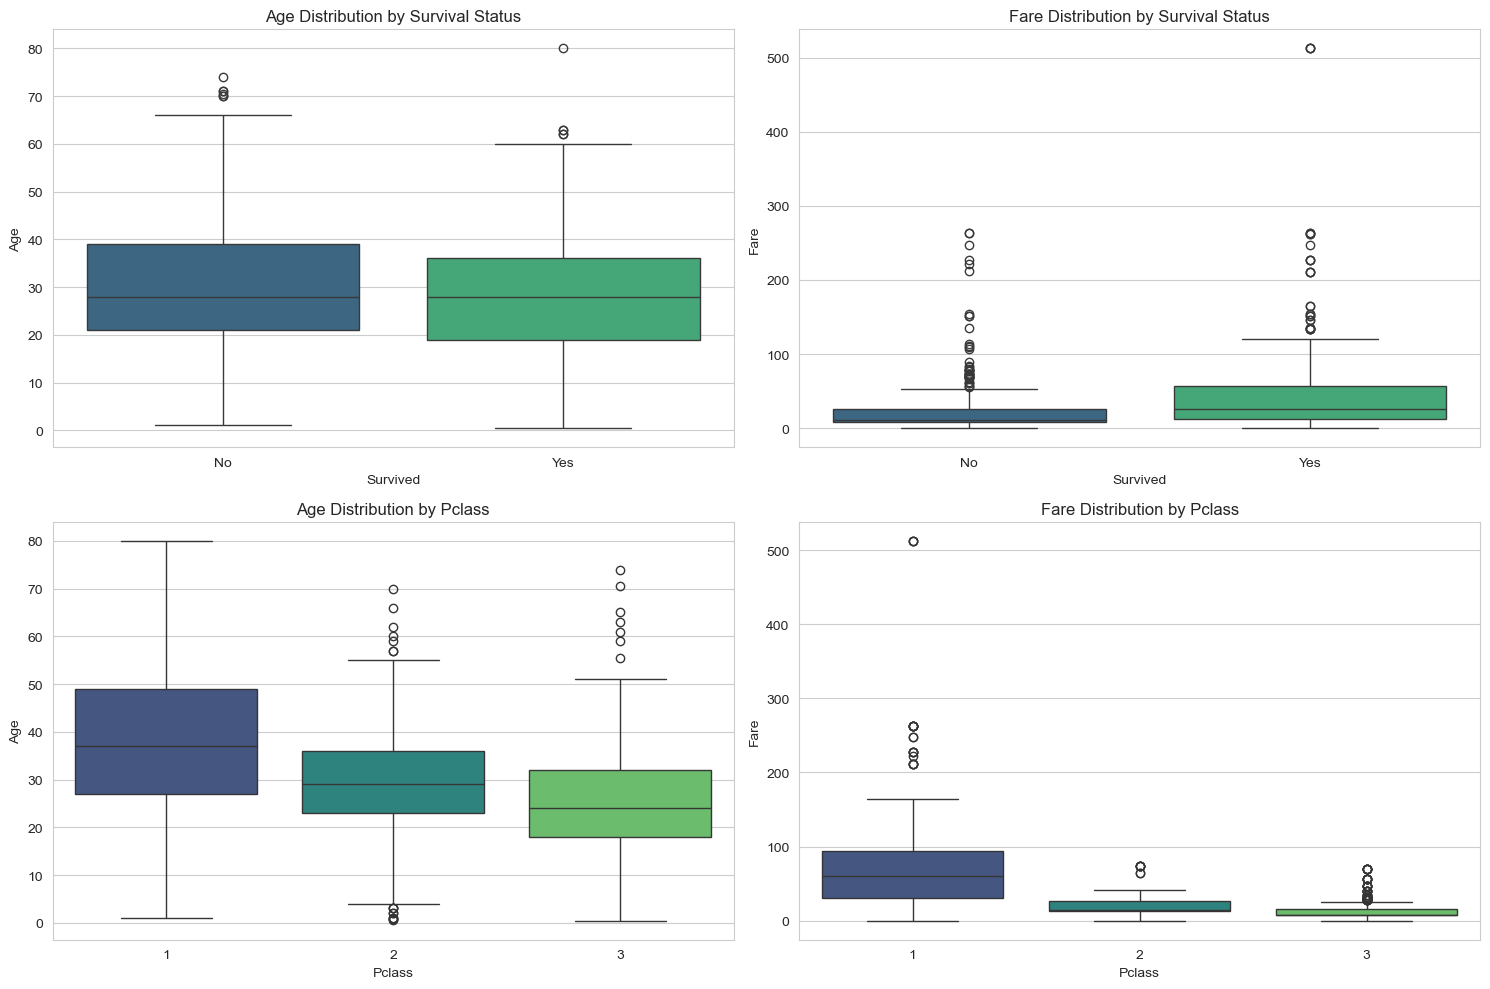

In [29]:
# 4. Box plots to explore relationships between numerical and categorical features
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='Survived', y='Age', palette='viridis')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Survived')
plt.ylabel('Age')
plt.xticks([0, 1], ['No', 'Yes'])

plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='Survived', y='Fare', palette='viridis')
plt.title('Fare Distribution by Survival Status')
plt.xlabel('Survived')
plt.ylabel('Fare')
plt.xticks([0, 1], ['No', 'Yes'])

plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='Pclass', y='Age', palette='viridis')
plt.title('Age Distribution by Pclass')
plt.xlabel('Pclass')
plt.ylabel('Age')

plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='Pclass', y='Fare', palette='viridis')
plt.title('Fare Distribution by Pclass')
plt.xlabel('Pclass')
plt.ylabel('Fare')

plt.tight_layout()
plt.show()

In [30]:
# 5. Calculate correlation matrix for numerical columns
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Survived', 'Pclass']
correlation_matrix = df[numerical_cols].corr()

In [ ]:
-0.7 to 0.7 strong correlation
0.4 to 0.6 weak
-0.3 to +0.3 no correlation

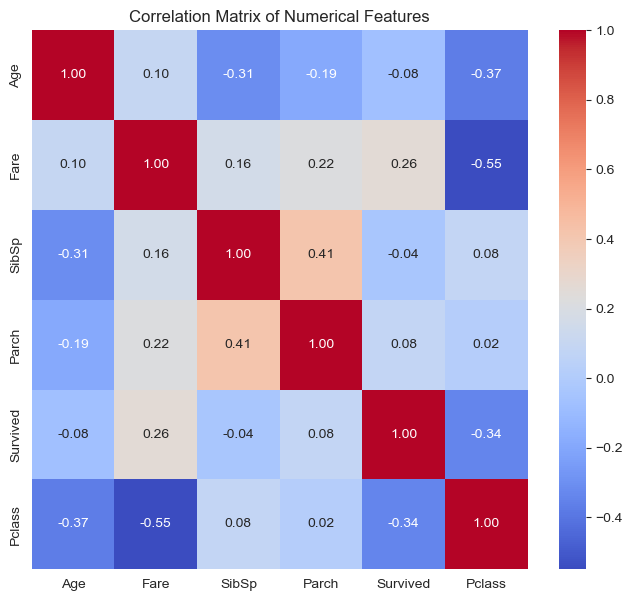

In [31]:
# 6. Generate a heatmap of the correlation matrix
plt.figure(figsize=(8, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()